In [27]:
import tensorflow as tf
from tensorflow.keras.layers import Dense
import sklearn as sk
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_circles
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from utils import show_first_five

## Generating Data

In [28]:
X, y = make_circles(
    n_samples=500,
    noise=0.08,
    factor=0.4,
    random_state=42
)


## Seeing Data


In [29]:
print(X.shape)
print(y.shape)

print(X[:5])
print(y[:5])

(500, 2)
(500,)
[[-0.37534845  0.19833199]
 [-0.1061581   0.99849163]
 [-0.35445221  0.02190658]
 [-0.63517376 -0.64203511]
 [-0.80399496  0.64833975]]
[1 0 1 0 0]


## Plotting Data

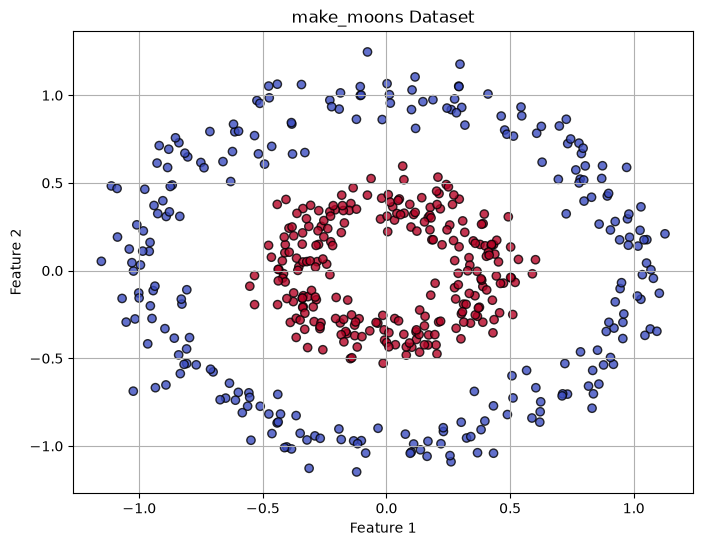

In [30]:
plt.figure(figsize=(8,6))

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="coolwarm", # Color Map list Below 👇
    edgecolors="k",
    alpha = 0.8
)
# ['PiYG', 'PRGn', 'BrBG', 'PuOr', 'RdGy', 'RdBu', 'RdYlBu', 'RdYlGn', \
    # 'Spectral', 'coolwarm', 'bwr', 'seismic', 'berlin', 'managua', 'vanimo']


plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("make_moons Dataset")
plt.grid(True)

plt.show()

## Train Test Splitting

In [31]:
x_train, _x, y_train, _y = train_test_split(X, y, test_size=0.3,random_state=True)
x_cv, x_test, y_cv, y_test = train_test_split(_x, _y, test_size=0.5,random_state=True)

print(x_train.shape, x_cv.shape, x_test.shape)

(350, 2) (75, 2) (75, 2)


In [32]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_cv_scaled = scaler.transform(x_cv)
x_test_scaled = scaler.transform(x_test)

x_cv_scaled[:5]

array([[ 1.47746426, -0.99066718],
       [ 0.73767223,  0.33737102],
       [-0.68891301,  0.19252541],
       [-1.29932929, -1.00642863],
       [-0.68605715,  0.66498638]])

## Built Model

In [33]:
tf.random.set_seed(1234)

model = tf.keras.Sequential([
    tf.keras.Input(shape=(2,)),
    Dense(25, activation='relu', name='L1'),
    Dense(15, activation='relu', name='L2'),
    Dense(1, activation='sigmoid', name='L3')
], name='Prototype_1')

model.compile(
    loss = tf.keras.losses.BinaryCrossentropy(),
    optimizer = tf.keras.optimizers.Adam(0.001),
    metrics=['accuracy']
)

In [34]:
model.summary()

Model: "Prototype_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ L1 (Dense)                      │ (None, 25)             │            75 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L2 (Dense)                      │ (None, 15)             │           390 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ L3 (Dense)                      │ (None, 1)              │            16 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481 (1.88 KB)

 Trainable params: 481 (1.88 KB)

 Non-trainable params: 0 (0.00 B)

## Training Model

In [35]:
history = model.fit(x_train_scaled, y_train, epochs=100, verbose=1, validation_data=(x_cv_scaled, y_cv))

Epoch 1/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 3s 35ms/step - accuracy: 0.5057 - loss: 0.6297 - val_accuracy: 0.4667 - val_loss: 0.6167
Epoch 2/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.5057 - loss: 0.6105 - val_accuracy: 0.4667 - val_loss: 0.6079
Epoch 3/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5086 - loss: 0.5937 - val_accuracy: 0.4667 - val_loss: 0.5989
Epoch 4/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5114 - loss: 0.5779 - val_accuracy: 0.4800 - val_loss: 0.5888
Epoch 5/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5314 - loss: 0.5621 - val_accuracy: 0.4933 - val_loss: 0.5774
Epoch 6/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5429 - loss: 0.5460 - val_accuracy: 0.5200 - val_loss: 0.5646
Epoch 7/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5514 - loss: 0.5289 - val_accuracy: 0.5333 - val_loss: 0.5485
Epoch 8/100
11/11 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6086 - loss: 0.5102 - val_accuracy: 0.573

## Checking How Well Is it Doing on Unseen Data

In [36]:
history_devset = model.evaluate(x_cv_scaled, y_cv)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - accuracy: 1.0000 - loss: 0.0038


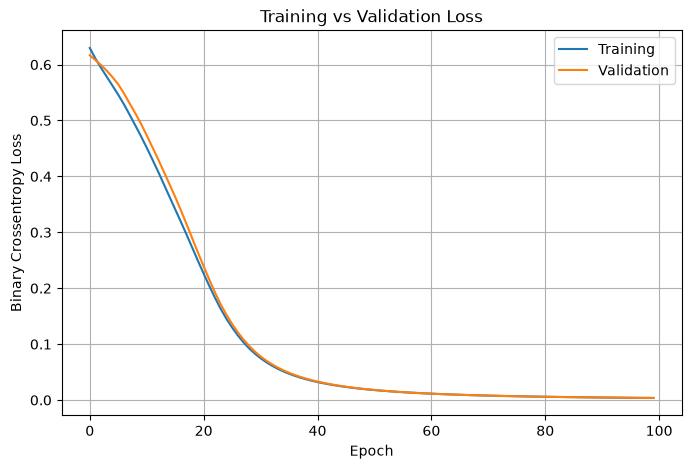

In [37]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Binary Crossentropy Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.grid(True)

plt.show()

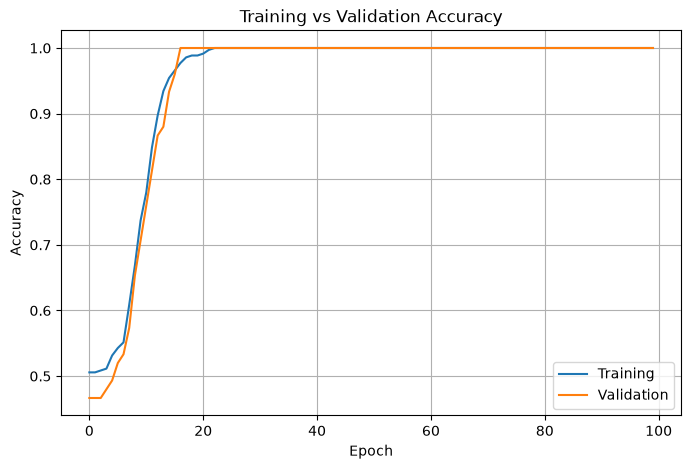

In [38]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)

plt.show()

In [39]:
# Creating grid

x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 300),
    np.linspace(y_min, y_max, 300)
)

grid = np.c_[xx.ravel(), yy.ravel()]

In [40]:
grid_scaled = scaler.transform(grid)
pred = model.predict(grid_scaled, verbose=0)
pred = pred.reshape(xx.shape)

## Plottinn the decision boundary

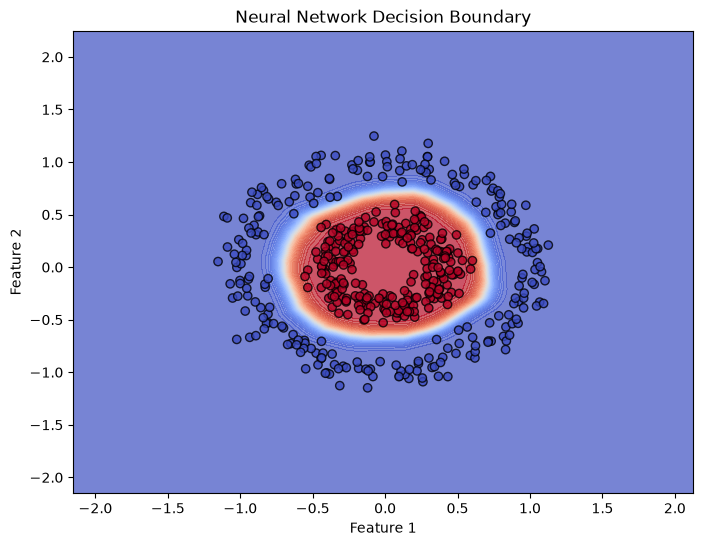

In [ ]:
plt.figure(figsize=(8,6))

plt.contourf(
    xx,
    yy,
    pred,
    levels=50,
    cmap="coolwarm",
    alpha=0.7
)

plt.scatter(
    X[:,0],
    X[:,1],
    c=y,
    cmap="coolwarm",
    edgecolors="k",
    alpha=0.8
)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Neural Network Decision Boundary")

plt.show()